# Analysing Openproblems Results

In [12]:
import os
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import time
import seaborn as sns  # optional, just for color if you like
import matplotlib.pyplot as plt

In [4]:
base_dir = "/Users/seohyon/resources/results"

rows = []

# Step 1 — Collect all rows
for folder in os.listdir(base_dir):
    folder_path = os.path.join(base_dir, folder)
    yaml_path = os.path.join(folder_path, "score_uns.yaml")
    
    if os.path.isdir(folder_path) and os.path.exists(yaml_path):
        with open(yaml_path, "r") as f:
            try:
                data = yaml.safe_load(f)
            except yaml.YAMLError as e:
                print(f"⚠️ Could not read {yaml_path}: {e}")
                continue

        for entry in data:
            metrics = entry.get("metric_ids", [])
            values = entry.get("metric_values", [])
            
            for m_id, m_val in zip(metrics, values):
                rows.append({
                    "dataset_id": entry.get("dataset_id"),
                    "file_size": entry.get("file_size"),
                    "method_id": entry.get("method_id"),
                    "normalization_id": entry.get("normalization_id"),
                    "metric_id": m_id,
                    "metric_value": m_val
                })

# Step 2 — Create one big DataFrame
df = pd.DataFrame(rows)

# Step 3 — Split into separate tables per dataset_id
datasets = {}
for dataset_id, sub_df in df.groupby("dataset_id"):
    datasets[dataset_id] = sub_df.reset_index(drop=True)
    print(f"\n=== Dataset: {dataset_id} ===")
    print(sub_df)

    # Optional: Save each dataset table as its own CSV
    safe_name = dataset_id.replace("/", "_")  # clean file name
    output_path = f"/Users/seohyon/resources/{safe_name}_scores.csv"
    sub_df.to_csv(output_path, index=False)
    print(f"✅ Saved to {output_path}")




=== Dataset: cellxgene_census/dkd ===
                 dataset_id  file_size                         method_id  \
1      cellxgene_census/dkd      22632                    no_integration   
2      cellxgene_census/dkd      22632                    no_integration   
4      cellxgene_census/dkd      22632              no_integration_batch   
20     cellxgene_census/dkd      22632                         harmonypy   
48     cellxgene_census/dkd      22632  shuffle_integration_by_cell_type   
...                     ...        ...                               ...   
18912  cellxgene_census/dkd      22632                             mnnpy   
18916  cellxgene_census/dkd      22632                  embed_cell_types   
18918  cellxgene_census/dkd      22632                      scgpt_mlflow   
18926  cellxgene_census/dkd      22632                               uce   
18927  cellxgene_census/dkd      22632                              scvi   

      normalization_id                metric_id 

## Mouse Pancreas

In [3]:
path = "/Users/seohyon/resources/cellxgene_census_mouse_pancreas_atlas_scores.csv"

df = pd.read_csv(path)

metrics = sorted(df["metric_id"].unique().tolist())

print("Unique metrics found:")
for m in metrics:
    print("-", m)

Unique metrics found:
- ari
- ari_batch
- asw_batch
- asw_label
- cell_cycle_conservation
- clisi
- graph_connectivity
- hvg_overlap
- ilisi
- isolated_label_asw
- isolated_label_f1
- kbet
- kbet_pg
- kbet_pg_label
- nmi
- nmi_batch
- pcr


I am assuming that higher score indicates better batch mixing

### Barplot for scores per metric

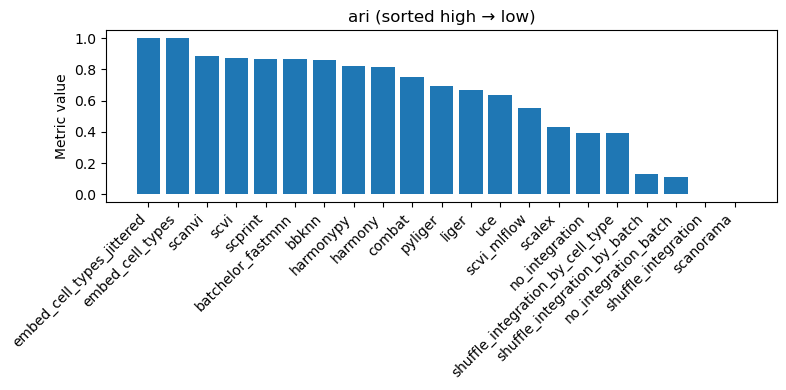

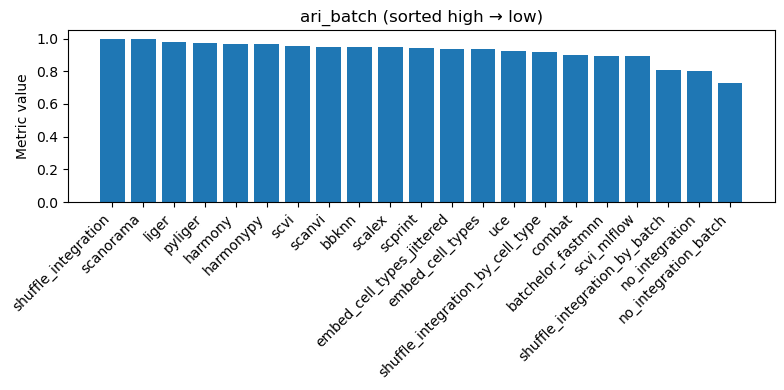

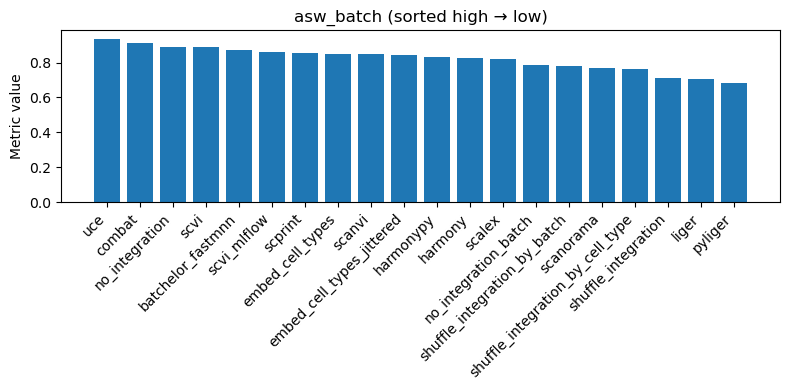

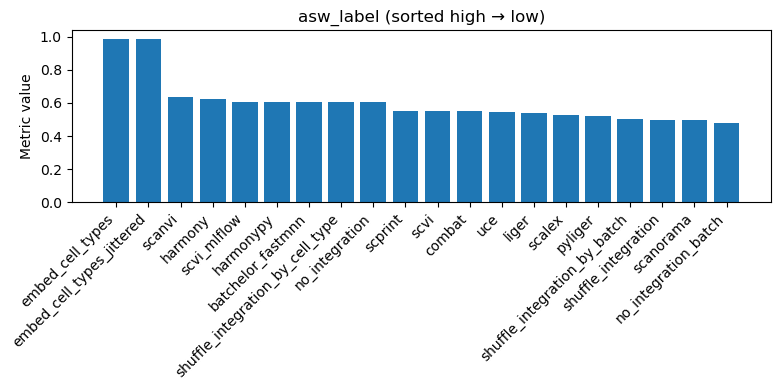

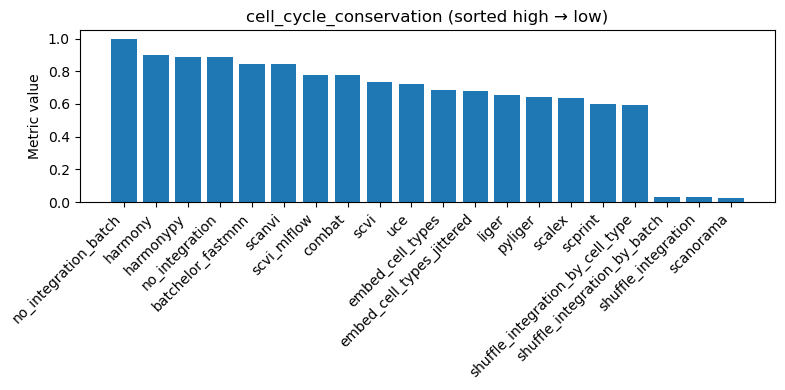

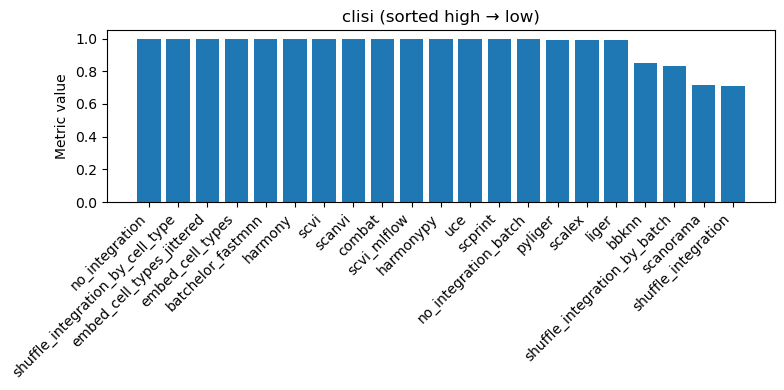

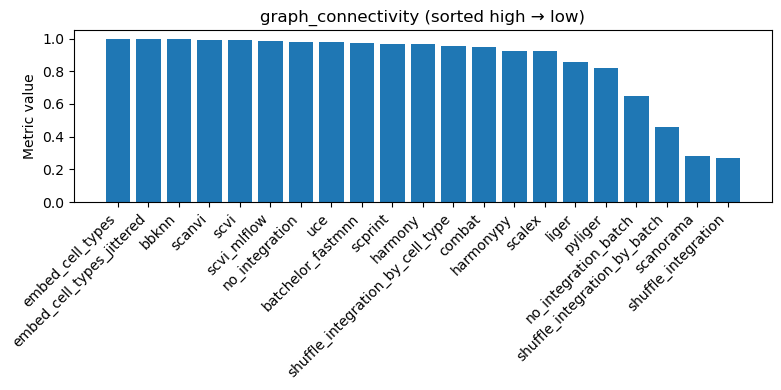

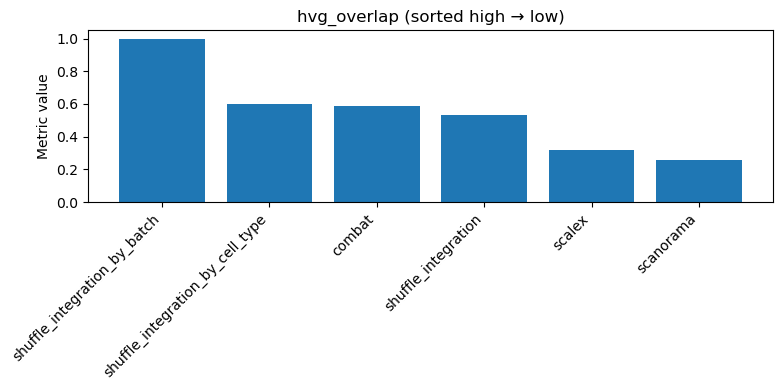

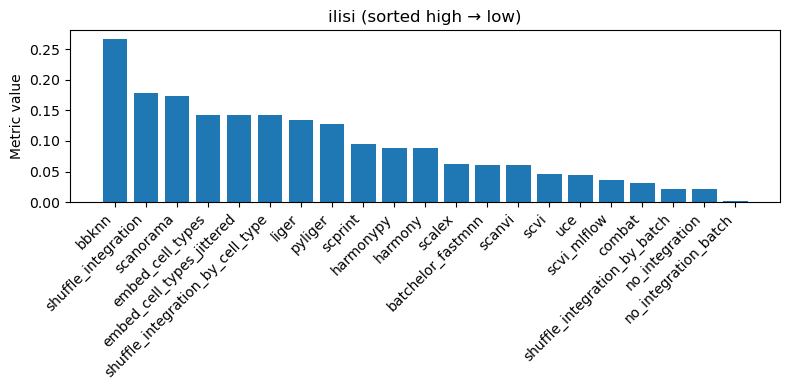

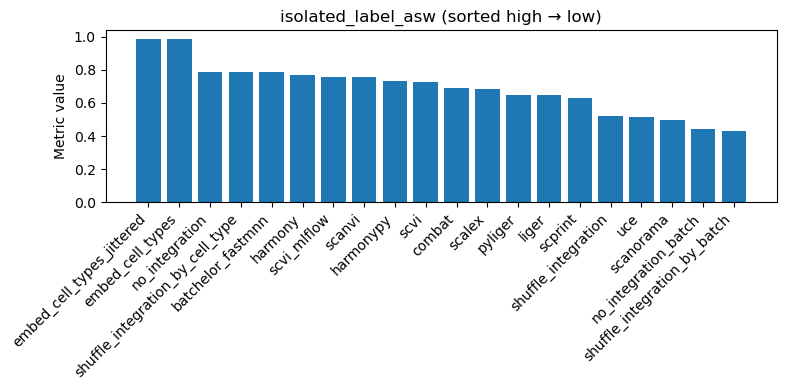

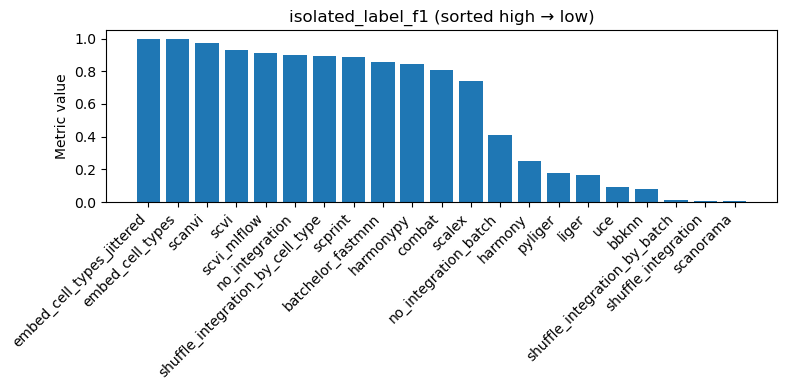

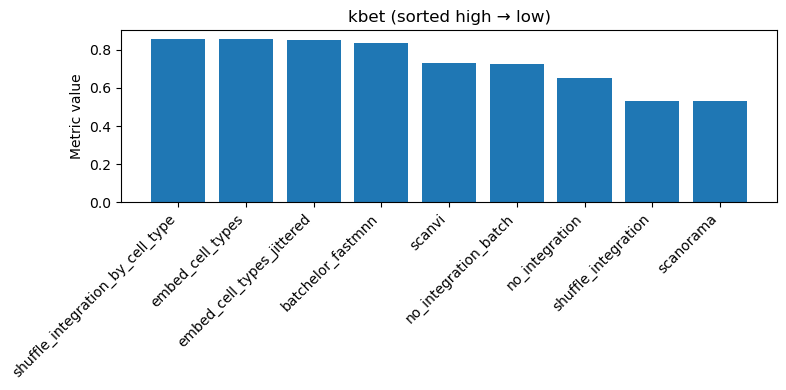

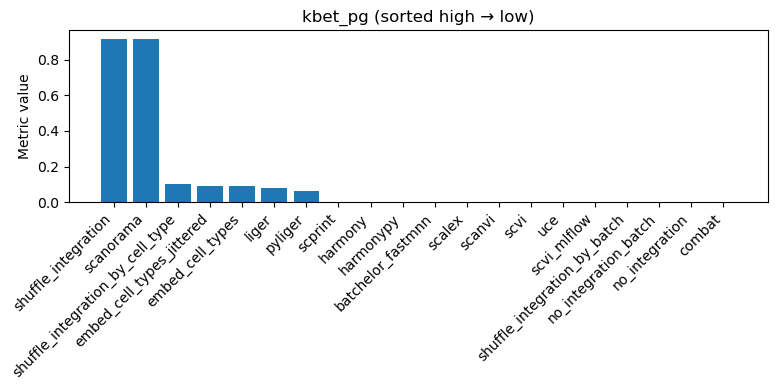

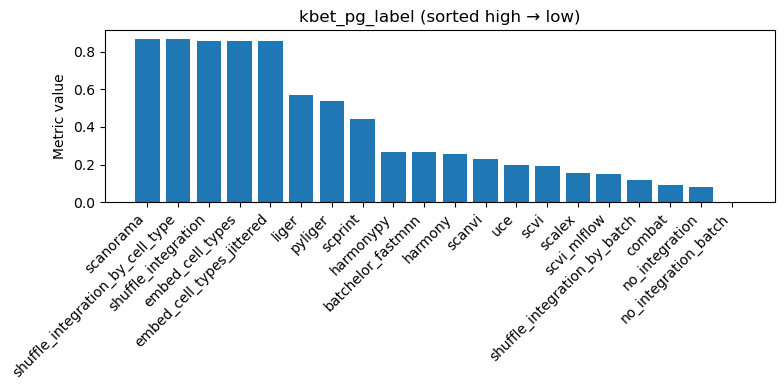

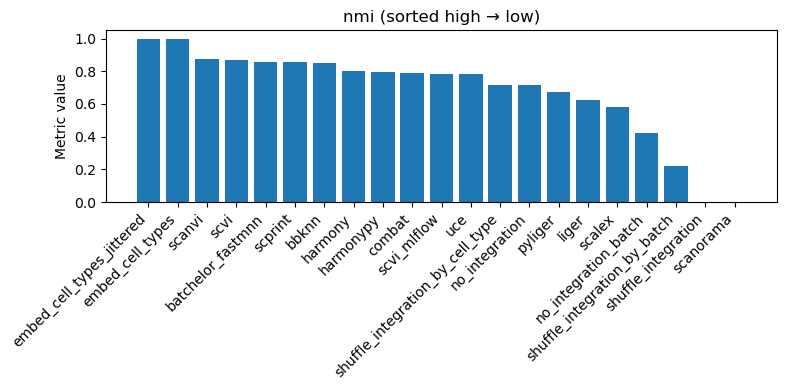

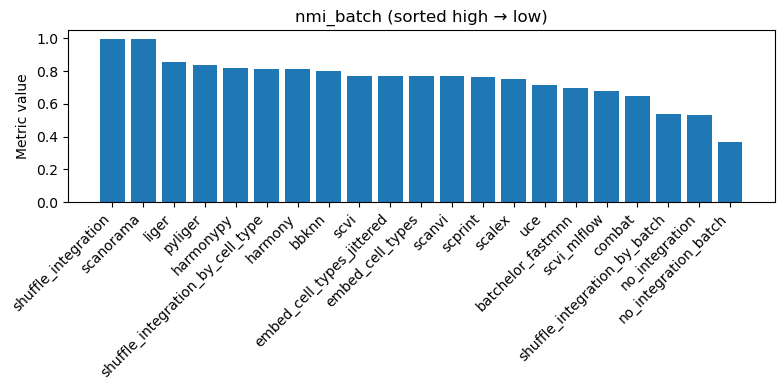

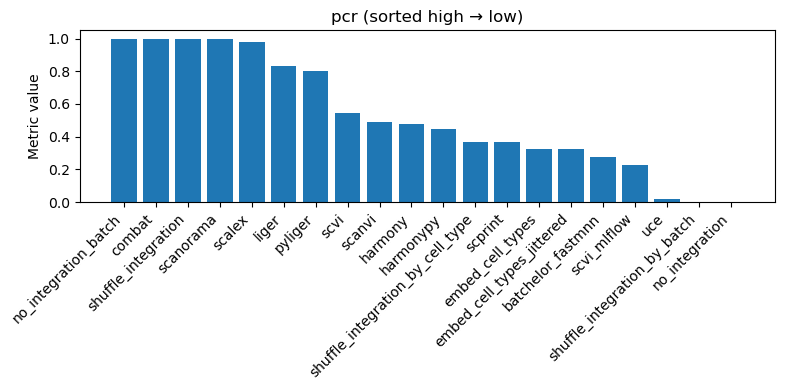

In [11]:
# Loop over each metric
for metric, sub in df.groupby("metric_id"):
    sub_sorted = sub.sort_values("metric_value", ascending=False)

    plt.figure(figsize=(8, 4))
    plt.bar(sub_sorted["method_id"], sub_sorted["metric_value"])
    plt.title(f"{metric} (sorted high → low)")
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Metric value")

    # Save figure per metric
#     safe_metric = metric.replace("/", "_")
#     plt.tight_layout()
#     plt.savefig(f"metric_{safe_metric}.png", dpi=150)
#     plt.close()

    plt.tight_layout()

    plt.show()  # display interactively

# print("✅ All metric bar plots saved as metric_<name>.png")

### Best and Worst Methods

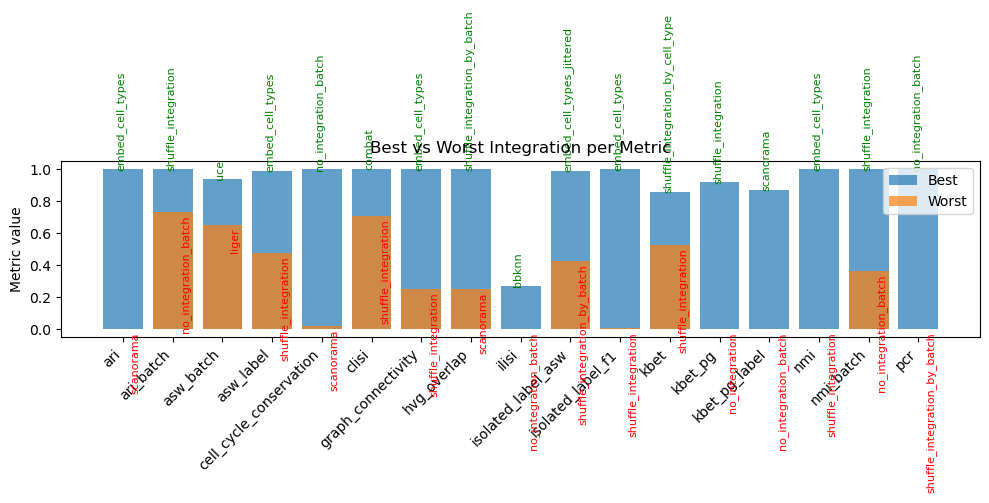

In [14]:
# Find best and worst methods for each metric
best_methods = df.loc[df.groupby("metric_id")["metric_value"].idxmax()]
worst_methods = df.loc[df.groupby("metric_id")["metric_value"].idxmin()]

plt.figure(figsize=(10, 5))

plt.bar(best_methods["metric_id"], best_methods["metric_value"], label="Best", alpha=0.7)
plt.bar(worst_methods["metric_id"], worst_methods["metric_value"], label="Worst", alpha=0.7)

# Add method names as labels above the bars
for i, (metric, val, method) in enumerate(zip(best_methods["metric_id"], best_methods["metric_value"], best_methods["method_id"])):
    plt.text(i - 0.15, val + 0.01, method, rotation=90, fontsize=8, color="green")

for i, (metric, val, method) in enumerate(zip(worst_methods["metric_id"], worst_methods["metric_value"], worst_methods["method_id"])):
    plt.text(i + 0.15, val - 0.02, method, rotation=90, fontsize=8, color="red", va="top")

# Cosmetics
plt.title("Best vs Worst Integration per Metric")
plt.ylabel("Metric value")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

Thoughts: ASW_batch has high metric scores for all of the methods. Let's look into no_integration_batch - this one is not integrated by batch but still got almost 0.8 with ASW_batch. Is ASW_batch reliable?

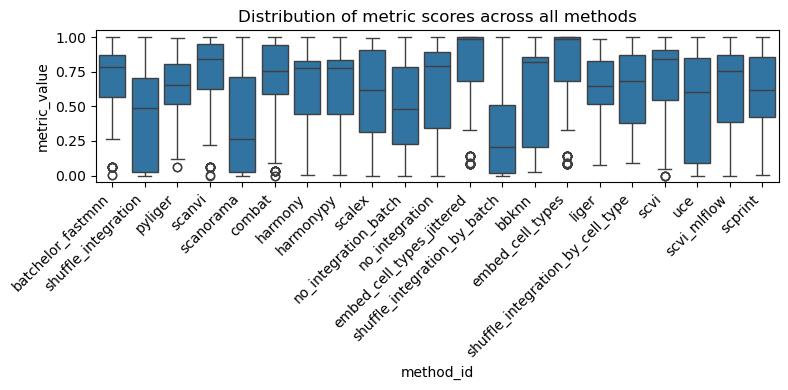

In [24]:
plt.figure(figsize=(8,4))
sns.boxplot(x="method_id", y="metric_value", data=df)
plt.title("Distribution of metric scores across all methods")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Can we trust the metrics? Without knowing every detail about each metrics?